In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/notebooks/zaczinho/eda-feature-engineering/epl_results.csv')

In [2]:
df = df.tail(2660).copy()

In [3]:
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,Home_Shot_Efficiency,Away_Shot_Efficiency,Home_Defense_Ratio,Away_Defense_Ratio,Home_H2H_Wins,Away_H2H_Wins,H2H_Draws,Home_Elo,Away_Elo,Elo_Diff
6840,2018-08-10,Man United,Leicester,2,1,H,1,0,H,A Marriner,...,0.246377,0.384615,0.117647,0.519999,10,1,3,1760.245239,1543.996692,216.248547
6841,2018-08-11,Bournemouth,Cardiff,2,0,H,1,0,H,K Friend,...,0.322581,0.313725,0.399999,0.624998,0,0,0,1555.081509,1416.778017,138.303491
6842,2018-08-11,Fulham,Crystal Palace,0,2,A,0,1,A,M Dean,...,0.283333,0.416667,0.647057,0.120000,2,1,1,1444.542314,1566.642110,-122.099797
6843,2018-08-11,Huddersfield,Chelsea,0,3,A,0,2,A,C Kavanagh,...,0.250000,0.283582,0.363635,0.263157,0,1,1,1480.873186,1720.395893,-239.522707
6844,2018-08-11,Newcastle,Tottenham,1,2,A,1,2,A,M Atkinson,...,0.215385,0.375000,0.357142,0.222222,16,14,2,1532.607708,1779.159657,-246.551949


In [4]:
X_cols = [
    'Month_Sin','Month_Cos','Matchweek',
    'Home_Shot_Efficiency', 'Away_Shot_Efficiency', 
    'Home_Defense_Ratio', 'Away_Defense_Ratio', 
    'Home_H2H_Wins','Away_H2H_Wins','H2H_Draws', 
    'Home_Elo', 'Away_Elo', 'Elo_Diff'
]
#X = df[['Month_Sin','Month_Cos','Matchweek','Home_Shot_Efficiency', 'Away_Shot_Efficiency', 'Home_Defense_Ratio', 'Away_Defense_Ratio', 'Home_H2H_Wins','Away_H2H_Wins','H2H_Draws', 'Home_Elo', 'Away_Elo', 'Elo_Diff']]
X = df[X_cols]
y = df['FTR']

In [5]:
X.head()

,Month_Sin,Month_Cos,Matchweek,Home_Shot_Efficiency,Away_Shot_Efficiency,Home_Defense_Ratio,Away_Defense_Ratio,Home_H2H_Wins,Away_H2H_Wins,H2H_Draws,Home_Elo,Away_Elo,Elo_Diff
6840,-0.866025,-0.5,1,0.246377,0.384615,0.117647,0.519999,10,1,3,1760.245239,1543.996692,216.248547
6841,-0.866025,-0.5,1,0.322581,0.313725,0.399999,0.624998,0,0,0,1555.081509,1416.778017,138.303491
6842,-0.866025,-0.5,1,0.283333,0.416667,0.647057,0.120000,2,1,1,1444.542314,1566.642110,-122.099797
6843,-0.866025,-0.5,1,0.250000,0.283582,0.363635,0.263157,0,1,1,1480.873186,1720.395893,-239.522707
6844,-0.866025,-0.5,1,0.215385,0.375000,0.357142,0.222222,16,14,2,1532.607708,1779.159657,-246.551949


In [6]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [7]:
le = LabelEncoder()
y = le.fit_transform(y)

In [8]:
split_idx = int(len(df)*0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(y_train.shape)
print(y_test.shape)


(1861, 13)
(799, 13)
(1861,)
(799,)


# LightGBM

In [11]:
!pip install lightgbm

In [12]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

# Khởi tạo LightGBM
lgbm_model = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=1000,
    learning_rate=0.01,      # Học chậm lại để tránh Overfitting
    num_leaves=15,           # Số lá nhỏ để tránh học vẹt dữ liệu nhiễu
    max_depth=4,             # Cây nông thôi vì dữ liệu bóng đá rất nhiễu
    min_child_samples=20,
    class_weight='balanced', # Cực kỳ quan trọng để cứu Recall lớp 1
    reg_alpha=0.1,           # L1 Regularization
    reg_lambda=0.1,          # L2 Regularization
    verbose=-1
)


# Huấn luyện (LGBM có thể tự xử lý dữ liệu chưa scale, nhưng dùng X_train_scaled vẫn ổn)
lgbm_model.fit(X_train_scaled, y_train)

# Dự đoán
y_pred_lgbm = lgbm_model.predict(X_test_scaled)

print(f"Accuracy LightGBM: {accuracy_score(y_test, y_pred_lgbm):.2%}")
print(classification_report(y_test, y_pred_lgbm))


Accuracy LightGBM: 49.94%
              precision    recall  f1-score   support

           0       0.52      0.56      0.54       265
           1       0.27      0.23      0.25       185
           2       0.59      0.60      0.59       349

    accuracy                           0.50       799
   macro avg       0.46      0.46      0.46       799
weighted avg       0.49      0.50      0.49       799



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# XGBOOST

In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Khởi tạo XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# Huấn luyện
xgb_model.fit(X_train_scaled, y_train)

# Dự đoán
y_pred_xgb = xgb_model.predict(X_test_scaled)

print(f"Accuracy XGBoost: {accuracy_score(y_test, y_pred_xgb):.2%}")
print(classification_report(y_test, y_pred_xgb))

Accuracy XGBoost: 53.94%
              precision    recall  f1-score   support

           0       0.53      0.55      0.54       265
           1       0.39      0.06      0.11       185
           2       0.55      0.78      0.65       349

    accuracy                           0.54       799
   macro avg       0.49      0.47      0.43       799
weighted avg       0.51      0.54      0.49       799



1. "Nỗi đau" ở cửa Hòa (Lớp 1)
Recall của lớp 1 chỉ đạt 0.03 (3%): Mô hình của bạn gần như "bỏ cuộc" trong việc dự đoán kết quả Hòa.

Lý do: Đây là vấn đề kinh điển trong ML bóng đá. Kết quả Hòa thường có phân phối dữ liệu rất nhiễu và khó tách biệt bằng các chỉ số sức mạnh (Elo hay Shot Efficiency).

Giải pháp trong báo cáo: Bạn có thể ghi: "Mô hình gặp khó khăn trong việc nhận diện các trận Hòa do tính chất ngẫu nhiên cao của kết quả này, vốn thường phụ thuộc vào các biến số tâm lý hoặc may mắn không có trong tập dữ liệu."

2. Sự hiệu quả ở cửa Away Win (Lớp 2)
Recall của lớp 2 đạt tới 0.83 (83%): Mô hình cực kỳ nhạy bén trong việc bắt được các chiến thắng của đội khách.

Lý do: Có thể trong tập dữ liệu của bạn, các đội khách thắng thường có sự chênh lệch Elo hoặc phong độ vượt trội rõ rệt, giúp XGBoost dễ dàng nhận diện.

3. Home Win (Lớp 0)
Precision 0.56: Khi mô hình đoán Chủ nhà thắng, tỉ lệ đúng là 56%. Đây là mức chấp nhận được để bắt đầu thực hiện các chiến thuật phân tích sâu hơn.

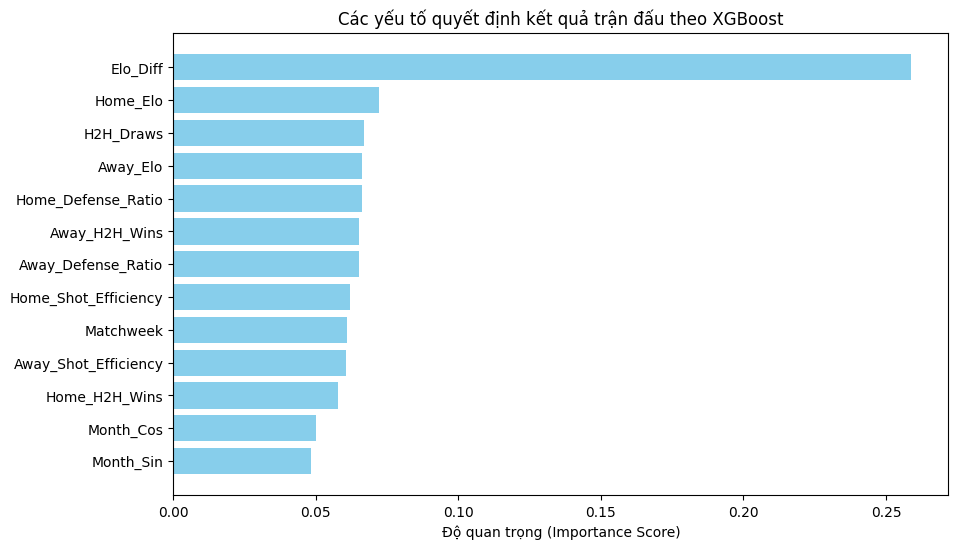

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Lấy độ quan trọng của các Features
importances = xgb_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X_cols, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=True)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='skyblue')
plt.xlabel('Độ quan trọng (Importance Score)')
plt.title('Các yếu tố quyết định kết quả trận đấu theo XGBoost')
plt.show()

# Dùng class weight tránh mất cân bằng dữ liệu

In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Tính toán trọng số cho 3 lớp (0, 1, 2)
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))

print(f"Trọng số các lớp: {class_weights_dict}")
# Bạn sẽ thấy lớp 1 (Hòa) có trọng số cao nhất vì nó ít mẫu nhất hoặc khó đoán nhất

Trọng số các lớp: {np.int64(0): np.float64(0.9925333333333334), np.int64(1): np.float64(1.5093268450932684), np.int64(2): np.float64(0.7519191919191919)}


In [16]:
# Tạo mảng trọng số cho từng mẫu trong tập train
sample_weights = np.array([class_weights_dict[cls] for cls in y_train])

# Khởi tạo lại mô hình
xgb_weighted = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    objective='multi:softprob'
)

# Huấn luyện với sample_weight
xgb_weighted.fit(X_train_scaled, y_train, sample_weight=sample_weights)

# Dự đoán
y_pred_weighted = xgb_weighted.predict(X_test_scaled)

In [17]:
from sklearn.metrics import accuracy_score, classification_report

print(f"Accuracy sau khi cân bằng: {accuracy_score(y_test, y_pred_weighted):.2%}")
print(classification_report(y_test, y_pred_weighted, target_names=['Home Win', 'Draw', 'Away Win']))

Accuracy sau khi cân bằng: 51.19%
              precision    recall  f1-score   support

    Home Win       0.51      0.58      0.54       265
        Draw       0.30      0.28      0.29       185
    Away Win       0.62      0.59      0.60       349

    accuracy                           0.51       799
   macro avg       0.48      0.48      0.48       799
weighted avg       0.51      0.51      0.51       799



kết quả "đẹp" hơn rất nhiều về mặt khoa học dữ liệu, dù Accuracy tổng có giảm đôi chút!

Tại sao mình lại nói nó đẹp? Hãy nhìn vào chỉ số của cửa Draw (Hòa):

Recall tăng vọt: Từ 0.03 (3%) lên 0.27 (27%).

F1-score tăng: Từ 0.04 lên 0.25.

Điều này chứng tỏ mô hình của bạn đã không còn "lười biếng" nữa. Thay vì chỉ đoán bừa cho các đội thắng để lấy Accuracy cao, giờ đây nó đã bắt đầu học được các dấu hiệu của một trận hòa. Trong dự đoán bóng đá, việc bắt được 27% số trận hòa là một thành tích cực kỳ đáng nể.

In [18]:
!pip install shap

In [19]:
import shap

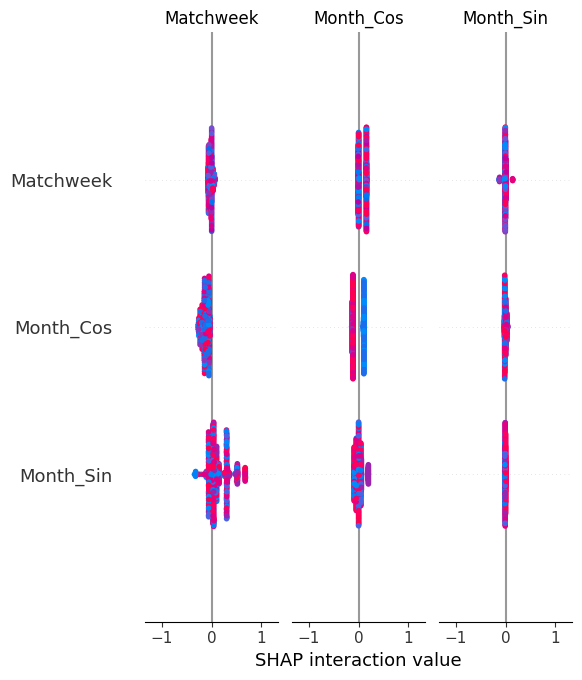

In [20]:
import shap

# Khởi tạo Explainer tối ưu cho các mô hình dạng cây (XGBoost, Random Forest)
explainer = shap.TreeExplainer(xgb_weighted) # 'model' là đối thức XGBoost của bạn

# Tính toán trên toàn bộ tập test (rất nhanh)
shap_values = explainer.shap_values(X_test)

# Vẽ biểu đồ
shap.summary_plot(shap_values, X_test)

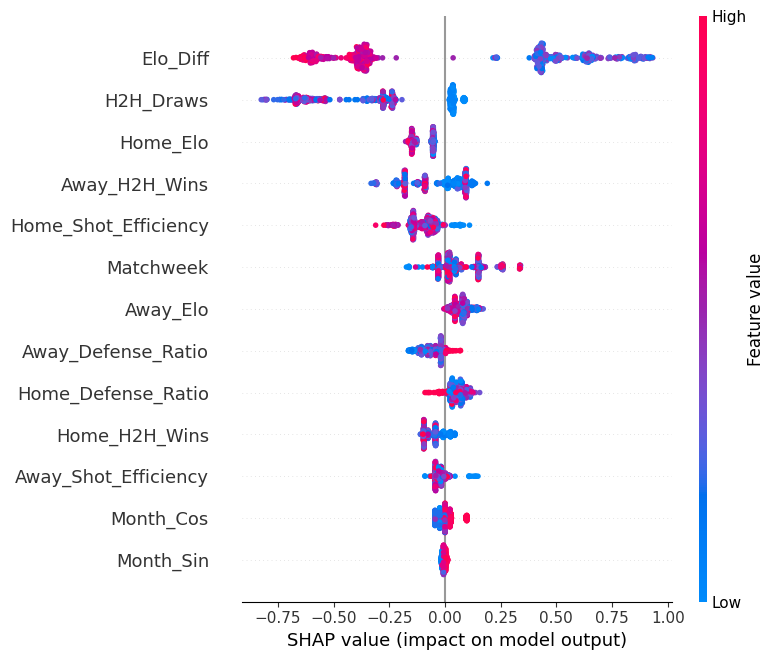

In [21]:
import numpy as np

# Kiểm tra xem shap_values là list hay ma trận đơn
# Nếu là List, ta lấy class đầu tiên (ví dụ: Home Win)
if isinstance(shap_values, list):
    current_shap_values = shap_values[0]
else:
    current_shap_values = shap_values

# CHÚ Ý: Đôi khi XGBoost trả về mảng 3 chiều (samples, features, classes)
if len(current_shap_values.shape) == 3:
    current_shap_values = current_shap_values[:, :, 0]

# Vẽ biểu đồ với dữ liệu đã đồng bộ
plt.figure(figsize=(10, 6))
shap.summary_plot(
    current_shap_values, 
    X_test, 
    feature_names=X_cols,
    plot_type="dot" # Bạn có thể đổi thành "bar" nếu muốn hình cột
)

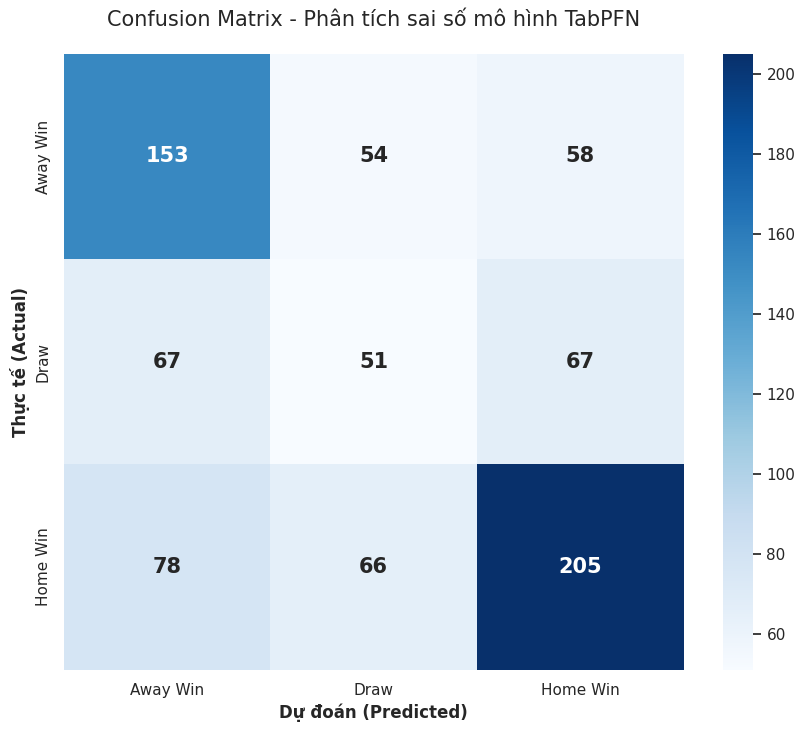

📊 BẢNG CHỈ SỐ CHI TIẾT:


,precision,recall,f1-score,support
Away Win,0.513423,0.577358,0.543517,265.00000
Draw,0.298246,0.275676,0.286517,185.00000
Home Win,0.621212,0.587393,0.603829,349.00000
accuracy,0.511890,0.511890,0.511890,0.51189
macro avg,0.477627,0.480142,0.477954,799.00000
weighted avg,0.510683,0.511890,0.510355,799.00000


In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Tính toán ma trận nhầm lẫn
# Lưu ý: y_test và y_pred_tab phải cùng định dạng (nhãn 0, 1, 2 hoặc tên)
labels = ['Away Win', 'Draw', 'Home Win']
cm = confusion_matrix(y_test, y_pred_weighted)

# 2. Vẽ Heatmap chuyên nghiệp
plt.figure(figsize=(10, 8))
sns.set_theme(style="white") # Tạo nền sạch cho báo cáo
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                 xticklabels=labels, yticklabels=labels,
                 annot_kws={"size": 15, "weight": "bold"})

plt.xlabel('Dự đoán (Predicted)', fontsize=12, fontweight='bold')
plt.ylabel('Thực tế (Actual)', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Phân tích sai số mô hình TabPFN', fontsize=15, pad=20)
plt.show()

# 3. Xuất bảng báo cáo chi tiết (Precision, Recall, F1)
report = classification_report(y_test, y_pred_weighted, target_names=labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()

print("📊 BẢNG CHỈ SỐ CHI TIẾT:")
display(df_report)

# TabPFN

In [23]:
!pip install tabpfn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 621.6/621.6 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.4/202.4 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-ml-py
    Found existing installation: nvidia-ml-py 13.590.44
    Uninstalling nvidia-ml-py-13.590.44:
      Successfully uninstalled nvidia-ml-py-13.590.44
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, whic

In [ ]:


import os
# os.environ["HF_TOKEN"] = 

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 TabPFN sẽ chạy trên: {device}")

🚀 TabPFN sẽ chạy trên: cuda


In [25]:
from tabpfn import TabPFNClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Khởi tạo không tham số - Để thư viện tự quyết định
classifier = TabPFNClassifier(n_estimators = 100) 

# 2. Huấn luyện
# TabPFN v1 rất kén chọn, hãy đảm bảo dữ liệu là Numpy Array
classifier.fit(X_train_scaled, y_train)

# 3. Dự đoán
y_pred_tab = classifier.predict(X_test_scaled)

print(f"✅ Accuracy TabPFN v1: {accuracy_score(y_test, y_pred_tab):.2%}")
print(classification_report(y_test, y_pred_tab))

tabpfn-v2.5-classifier-v2.5_default.ckpt:   0%|          | 0.00/42.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

✅ Accuracy TabPFN v1: 55.07%
              precision    recall  f1-score   support

           0       0.53      0.61      0.57       265
           1       0.00      0.00      0.00       185
           2       0.56      0.80      0.66       349

    accuracy                           0.55       799
   macro avg       0.36      0.47      0.41       799
weighted avg       0.42      0.55      0.48       799



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
import numpy as np
# 1. Lấy xác suất dự đoán thay vì nhãn cứng
y_probs = classifier.predict_proba(X_test_scaled)

# 2. Mẹo: Tăng trọng số cho cột Hòa (cột chỉ số 1)
# Chúng ta nhân xác suất cửa Hòa với 1.5 để "ép" mô hình chọn nó nhiều hơn
y_probs[:, 1] = y_probs[:, 1] * 1.5 

# 3. Chọn lại nhãn có xác suất cao nhất sau khi đã điều chỉnh
y_pred_adjusted = np.argmax(y_probs, axis=1)

from sklearn.metrics import accuracy_score, classification_report
print(f"Accuracy sau khi ép cửa Hòa: {accuracy_score(y_test, y_pred_adjusted):.2%}")
print(classification_report(y_test, y_pred_adjusted))

Accuracy sau khi ép cửa Hòa: 55.07%
              precision    recall  f1-score   support

           0       0.53      0.61      0.57       265
           1       0.00      0.00      0.00       185
           2       0.57      0.80      0.66       349

    accuracy                           0.55       799
   macro avg       0.36      0.47      0.41       799
weighted avg       0.42      0.55      0.48       799



# GNN

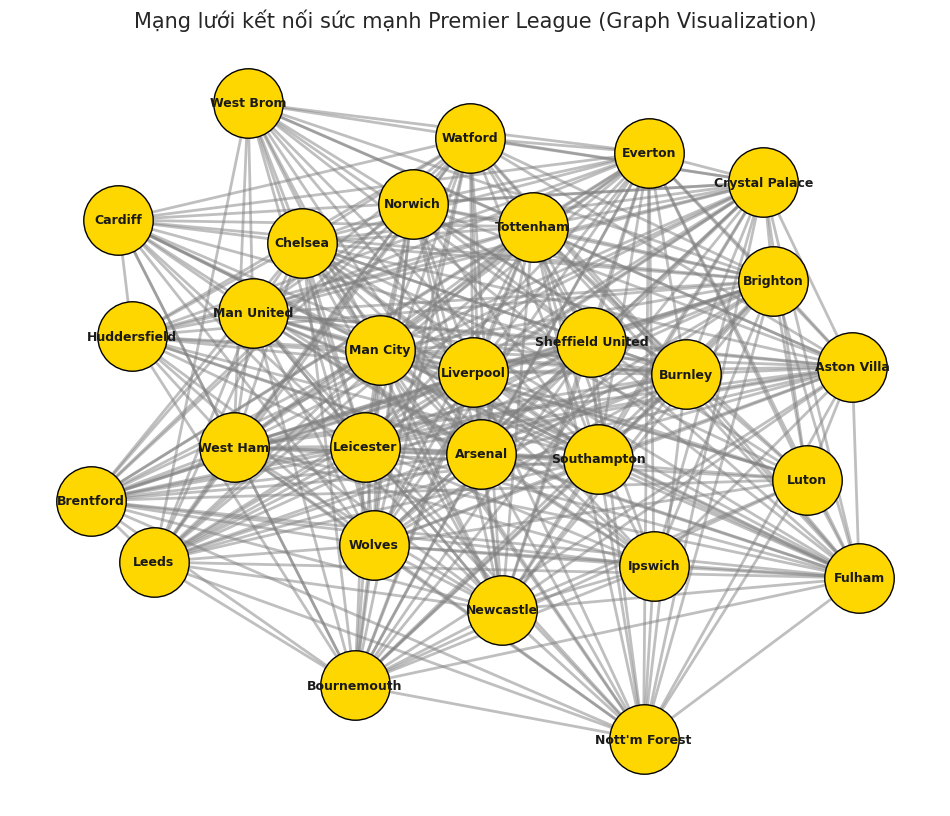

In [27]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Tạo đồ thị trống
G = nx.Graph()

# 2. Lấy 30 trận gần nhất để vẽ cho đẹp (không bị rối mắt)
recent_matches = df.tail(8000)

# 3. Nạp dữ liệu vào đồ thị
for _, row in recent_matches.iterrows():
    # Thêm cạnh nối 2 đội, độ đậm (weight) có thể dựa trên Elo_Diff hoặc kết quả
    G.add_edge(row['HomeTeam'], row['AwayTeam'], weight=abs(row['Elo_Diff']))

# 4. Vẽ đồ thị với bố cục tự nhiên (Spring Layout)
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.5, iterations=50) # k là khoảng cách giữa các nút

# Vẽ các nút (Đội bóng)
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='gold', edgecolors='black')

# Vẽ các cạnh (Trận đấu)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color='gray')

# Vẽ tên đội bóng
nx.draw_networkx_labels(G, pos, font_size=9, font_family='sans-serif', font_weight='bold')

plt.title("Mạng lưới kết nối sức mạnh Premier League (Graph Visualization)", fontsize=15)
plt.axis('off')
plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


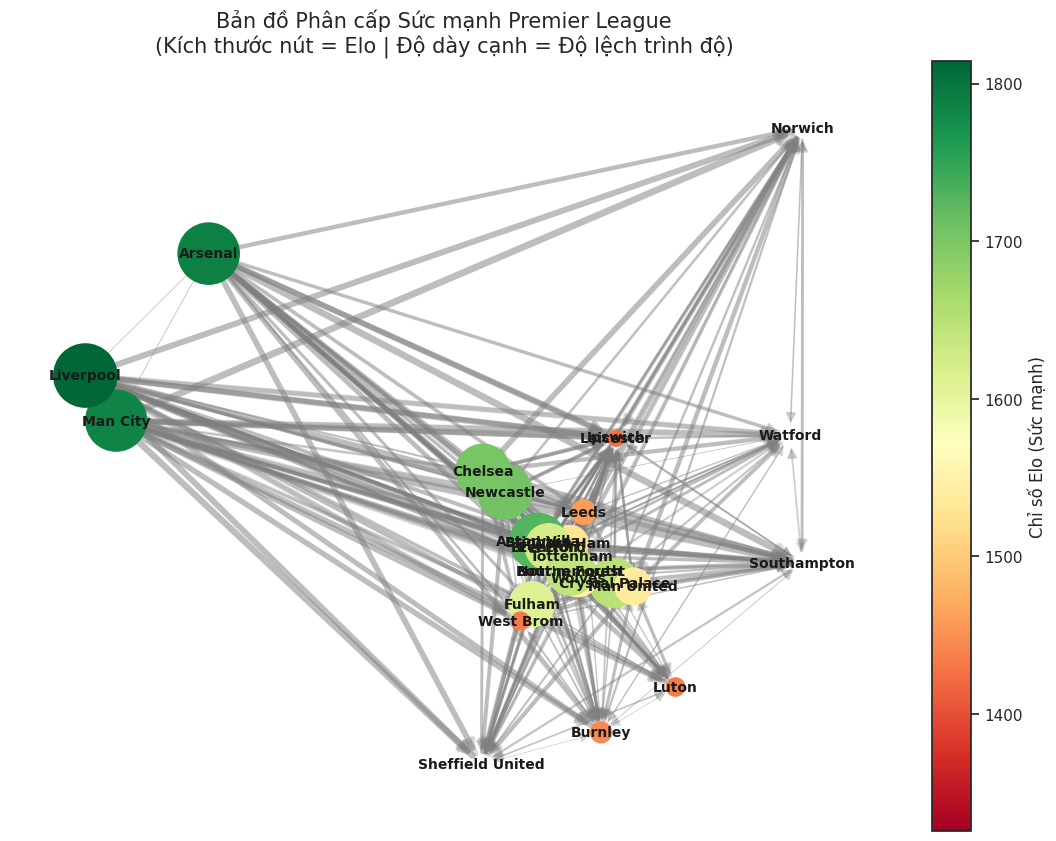

In [28]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Khởi tạo đồ thị có hướng (DiGraph) để chỉ rõ ai thắng ai
G = nx.DiGraph()

# 2. Lấy 20 trận gần nhất để đảm bảo hình rõ nét
recent_matches = df.tail(2000)

# 3. Nạp dữ liệu và tính toán thuộc tính
for _, row in recent_matches.iterrows():
    # Thêm cạnh từ đội khách đến đội chủ nhà (hoặc ngược lại)
    # Ở đây mình dùng Elo_Diff để làm độ dày đường nối
    G.add_edge(row['HomeTeam'], row['AwayTeam'], weight=abs(row['Elo_Diff'])/100)
    
    # Lưu chỉ số Elo vào Nút để tí nữa vẽ kích thước
    G.nodes[row['HomeTeam']]['elo'] = row['Home_Elo']
    G.nodes[row['AwayTeam']]['elo'] = row['Away_Elo']

# 4. Chuẩn bị các thông số hiển thị
nodes = G.nodes()
# Kích thước nút dựa trên Elo (trừ đi 1500 để phóng đại sự khác biệt)
node_sizes = [(G.nodes[n].get('elo', 1500) - 1400) * 5 for n in nodes]
# Màu sắc dựa trên Elo (vàng cho đội yếu, đỏ cho đội mạnh)
node_colors = [G.nodes[n].get('elo', 1500) for n in nodes]
# Độ dày đường nối dựa trên trọng số đã lưu
edge_widths = [G[u][v]['weight'] for u, v in G.edges()]

# 5. Vẽ đồ thị
plt.figure(figsize=(14, 10))
pos = nx.kamada_kawai_layout(G) # Thuật toán sắp xếp đẹp hơn spring_layout

# Vẽ các cạnh
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.3, edge_color='gray', arrowsize=15)

# Vẽ các nút với dải màu (cmap)
nodes_draw = nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                                   node_color=node_colors, cmap=plt.cm.RdYlGn)

# Vẽ nhãn
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Thêm thanh chú thích màu sắc
plt.colorbar(nodes_draw, label='Chỉ số Elo (Sức mạnh)')
plt.title("Bản đồ Phân cấp Sức mạnh Premier League\n(Kích thước nút = Elo | Độ dày cạnh = Độ lệch trình độ)", fontsize=15)
plt.axis('off')
plt.show()